## Polytope Extremes-DT example notebook

This notebook shows how to use earthkit-data and earthkit-plots to pull destination-earth data from LUMI and plot it using earthkit-plots.


Before running the notebook you need to set up your credentials. See the main readme of this repository for different ways to do this or use the following cells to authenticate.

You will need to generate your credentials using the desp-authentication.py script.

This can be run as follows:

In [ ]:
%%capture cap
%run desp-authentication.py

This will generate a token that can then be used by earthkit and polytope.

In [4]:
output_1 = cap.stdout.split('}\n')
access_token = output_1[-1][0:-1]

# Requirements
To run this notebook install the following:
* pip install earthkit-data
* pip install earthkit-regrid  (Optional for spectral variables)
* pip install cf-units         (Optional for unit conversion in maps)

In [5]:
import earthkit.data
import earthkit.regrid
from polytope.api import Client

In [6]:
# Set True if you want to make a live request for the data, or false if you want to use the cached grib file
LIVE_REQUEST = True

### Set parameter

In [ ]:
request = {
        "class": "d1",
        "expver": "0001",
        "stream": "oper",
        "dataset": "extremes-dt",
        # "date": "-14",
        "time": "0000",
        "type": "fc",
        "levtype": "sfc",
        "step": "0",
        "param": "228219",
        "date": "20260317",
        "feature": {
            "type": "boundingbox",
            "points": [
                [42.681885, 39.068247],   # SW corner
                [43.059540, 39.372526]    # north-east corner
            ],
            "axes": ["latitude", "longitude"]
        }
       
    }

In [9]:
from pathlib import Path

data_file = "data/extremes-dt-earthkit-example.grib"
Path("data").mkdir(exist_ok=True)

data = earthkit.data.from_source(
    "polytope",
    "destination-earth",
    request,
    address="polytope.lumi.apps.dte.destination-earth.eu"
)

2026-03-12 15:47:22 - INFO - Key read from /home/koenifra/.polytopeapirc
2026-03-12 15:47:22 - INFO - Sending request...
{'request': 'class: d1\n'
            'dataset: extremes-dt\n'
            "date: '20260309'\n"
            "expver: '0001'\n"
            'feature:\n'
            '  axes:\n'
            '  - latitude\n'
            '  - longitude\n'
            '  points:\n'
            '  - - 31.842566\n'
            '    - 10.283203\n'
            '  - - 33.330528\n'
            '    - 12.598572\n'
            '  type: boundingbox\n'
            'levtype: sfc\n'
            "param: '228219'\n"
            "step: '0'\n"
            'stream: oper\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-03-12 15:47:22 - INFO - Polytope user key found in session cache for user koenifra


2026-03-12 15:47:23 - INFO - Request accepted. Please poll ./e7336719-652b-4654-a78b-5a97ab6163dc for status
2026-03-12 15:47:23 - INFO - Polytope user key found in session cache for user koenifra
2026-03-12 15:47:23 - INFO - Checking request status (e7336719-652b-4654-a78b-5a97ab6163dc)...
2026-03-12 15:47:23 - INFO - The current status of the request is 'queued'
2026-03-12 15:47:24 - INFO - The current status of the request is 'processing'
2026-03-12 15:47:29 - INFO - The current status of the request is 'processed'


In [10]:

# Materialize the stream into fields
fields = list(data)

# Convert first field to xarray
ds = fields[0].to_xarray()


In [11]:
print(ds)

<xarray.Dataset> Size: 71kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 1769)
Coordinates:
  * datetimes  (datetimes) <U20 80B '2026-03-09T00:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 14kB 0 1 2 3 4 5 ... 1763 1764 1765 1766 1767 1768
    latitude   (points) float64 14kB 31.87 31.87 31.87 ... 33.31 33.31 33.31
    longitude  (points) float64 14kB 10.31 10.37 10.42 ... 12.47 12.52 12.58
    levelist   (points) float64 14kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    lsrr       (datetimes, number, steps, points) float64 14kB 5.588e-09 ... 0.0
Attributes:
    class:          d1
    dataset:        extremes-dt
    Forecast date:  2026-03-09T00:00:00Z
    expver:         0001
    levtype:        sfc
    step:           0
    stream:         oper
    type:           fc
    number:         0
    date:           2026-03-09T00:00:00Z


In [12]:
ds

<xarray.Dataset> Size: 71kB
Dimensions:    (datetimes: 1, number: 1, steps: 1, points: 1769)
Coordinates:
  * datetimes  (datetimes) <U20 80B '2026-03-09T00:00:00Z'
  * number     (number) int64 8B 0
  * steps      (steps) int64 8B 0
  * points     (points) int64 14kB 0 1 2 3 4 5 ... 1763 1764 1765 1766 1767 1768
    latitude   (points) float64 14kB 31.87 31.87 31.87 ... 33.31 33.31 33.31
    longitude  (points) float64 14kB 10.31 10.37 10.42 ... 12.47 12.52 12.58
    levelist   (points) float64 14kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables:
    lsrr       (datetimes, number, steps, points) float64 14kB 5.588e-09 ... 0.0
Attributes:
    class:          d1
    dataset:        extremes-dt
    Forecast date:  2026-03-09T00:00:00Z
    expver:         0001
    levtype:        sfc
    step:           0
    stream:         oper
    type:           fc
    number:         0
    date:           2026-03-09T00:00:00Z

### Plot distribution of values

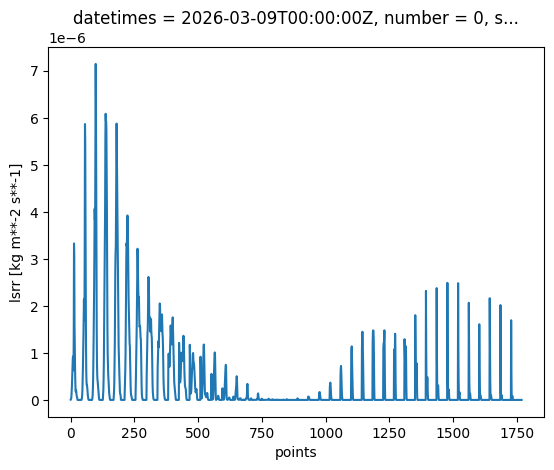

In [ ]:

import matplotlib
ds[list(ds.data_vars)[0]].plot()

In [15]:
rain = ds["lsrr"].isel(datetimes=0, number=0, steps=0)

In [16]:
mask = rain > 0

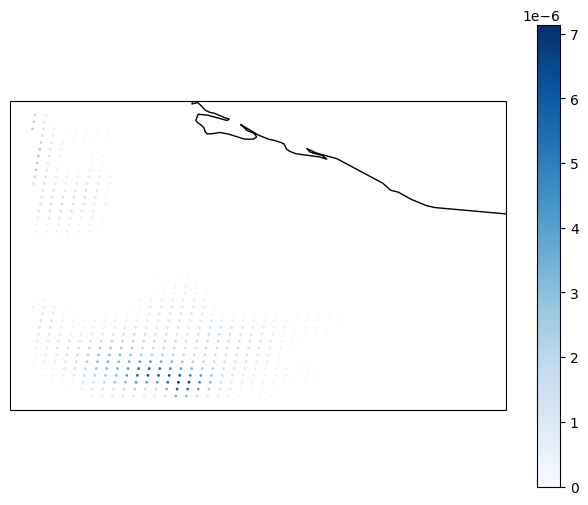

In [17]:
import matplotlib.pyplot as plt

import cartopy.crs as ccrs

fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())

sc = ax.scatter(
    ds.longitude,
    ds.latitude,
    c=rain,
    s=1,
    cmap="Blues",
    transform=ccrs.PlateCarree()
)

ax.coastlines()
plt.colorbar(sc)
plt.show()

In [19]:
rain

<xarray.DataArray 'lsrr' (points: 1769)> Size: 14kB
array([5.58793545e-09, 1.49011612e-08, 3.91155481e-08, ...,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00], shape=(1769,))
Coordinates:
    datetimes  <U20 80B '2026-03-09T00:00:00Z'
    number     int64 8B 0
    steps      int64 8B 0
  * points     (points) int64 14kB 0 1 2 3 4 5 ... 1763 1764 1765 1766 1767 1768
    latitude   (points) float64 14kB 31.87 31.87 31.87 ... 33.31 33.31 33.31
    longitude  (points) float64 14kB 10.31 10.37 10.42 ... 12.47 12.52 12.58
    levelist   (points) float64 14kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    type:       Parameter
    units:      kg m**-2 s**-1
    long_name:  lsrr

### Create raster from data and safe it

In [21]:
import numpy as np
from scipy.interpolate import griddata

rain = ds["lsrr"].isel(datetimes=0, number=0, steps=0)

lon = ds.longitude.values
lat = ds.latitude.values
values = rain.values

In [22]:
grid_lon, grid_lat = np.meshgrid(
    np.linspace(lon.min(), lon.max(), 200),
    np.linspace(lat.min(), lat.max(), 200)
)

In [23]:
grid_rain = griddata(
    (lon, lat),
    values,
    (grid_lon, grid_lat),
    method="linear"
)

In [24]:
import rasterio
from rasterio.transform import from_bounds

height, width = grid_rain.shape

transform = from_bounds(
    lon.min(), lat.min(),
    lon.max(), lat.max(),
    width, height
)

with rasterio.open(
    "DTweatherextremes_libya.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype=grid_rain.dtype,
    crs="EPSG:4326",
    transform=transform,
) as dst:
    dst.write(grid_rain, 1)